In [13]:
#No linux:



#(base) fabiene@$ conda env list
# conda environments:
#
#base                  *  /home/fabiene/anaconda3
#Maq2                     /home/fabiene/anaconda3/envs/Maq2
#RBA_est                  /home/fabiene/anaconda3/envs/RBA_est
#Robyn                    /home/fabiene/anaconda3/envs/Robyn
#Udemy                    /home/fabiene/anaconda3/envs/Udemy
#YouTube                  /home/fabiene/anaconda3/envs/YouTube
#pycaret-env              /home/fabiene/anaconda3/envs/pycaret-env

#(base) fabiene@$ conda activate YouTube
#(YouTube) fabiene@$ 




### Self organizing maps shap

 fontes:
 https://github.com/lamfo-unb/self-organizing-maps/blob/master/data/processed/start-business.csv
 
 https://lamfo-unb.github.io/2020/08/29/Self-organizing-maps/
 
https://medium.com/@abhinavr8/self-organizing-maps-ff5853a118d4

https://github.com/JustGlowing/minisom/blob/master/examples/DemocracyIndex.ipynb

https://github.com/lamfo-unb/self-organizing-maps/tree/master/modulos

O self-organizing map (SOM) é um modelo neural não supervisonado.

self-organizing maps (SOM)

## Usando SOM para visualizar em Python a facilidade de abrir negócios no mundo

Além do pandas vamos carregar a função scale do sklean para transformar as variáveis para o mesmo range de valores, a classe MiniSom do biblioteca minisom para realizar o treinamento do Self-organizing maps, por fim, a classe Mapa que foi criada por nós para plotar os mapas.

In [14]:
import pandas as pd
from sklearn.preprocessing import scale
from minisom import MiniSom

from modulos.mapa import Mapa

In [15]:
#!pip install minisom


In [16]:
path_data = 'start-business.csv'
read_params = {'sep': ';', 'decimal': ',', 'encoding': 'cp1252'}
dados = pd.read_csv(path_data, **read_params)
dados.head()

,country_code,economy,region,income_group,facility_group,score,procedures_man,time_men,cost_men,procedures_woman,time_woman,cost_woman,paid_in_min
0,AFG,Afghanistan,South Asia,Low income,High facility,92.04130,4.0,8.0,6.4,5.0,9.0,6.4,0.0
1,ALB,Albania,Europe & Central Asia,Upper middle income,High facility,91.70203,5.0,4.5,11.3,5.0,4.5,11.3,0.0
2,DZA,Algeria,Middle East & North Africa,Upper middle income,Low facility,77.94755,12.0,18.0,11.8,12.0,18.0,11.8,0.0
3,AGO,Angola,Sub-Saharan Africa,Lower middle income,Low facility,79.04553,8.0,36.0,13.9,8.0,36.0,13.9,0.0
4,ATG,Antigua and Barbuda,Latin America & Caribbean,High income,Lower middle facility,81.74620,9.0,22.0,8.7,9.0,22.0,8.7,0.0


## vamos selecionar apenas as variáveis que compõem o índice de facilidade e colocar essas variáveis na mesma escala.



In [17]:
features = ['procedures_man', 'time_men', 'cost_men', 'procedures_woman', 'time_woman', 'cost_woman','paid_in_min']
labels_contry = dados['country_code']
X = dados[features].values
X = scale(X)

Agora vamos treinar o Self-organizing maps com um mapa $15X15$ usando uma função de vizinhança gaussiana e treinando $1.000$ epochs.

In [18]:
size = 15
som = MiniSom(x=size, y=size, input_len=len(X[0]), sigma=1.5, neighborhood_function='gaussian', random_seed=1)
som.pca_weights_init(X)
som.train_random(X, 1000, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.370335065995795


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


Vamos agora instanciar a classe Mapa para plotar os mapas:

In [19]:
mapa = Mapa(som, X, labels_contry, size)


In [20]:
mapa

No gráfico vamos plotar a posição relativa dos países e atribuir uma cor para cada país de acordo com a variável facility_group. Essa variável foi construída a partir dos quartis da variável score: os países pertencentes ao primeiro quartil dessa variável foram classificados como Low facility, para indicar a baixa facilidade de abrir um novo negócio, e assim sucessivamente até o quarto quartil, no qual os países pertencentes a eles foram classificados como High facility.

In [21]:
facility_colors = {
    'Low facility': '#DC143C', 'Lower middle facility': '#FFA500', 'Upper middle facility': '#9370DB',
    'High facility': '#4B0082'
}
country_start_colors = [facility_colors[facility] for facility in dados['facility_group'].to_list()]

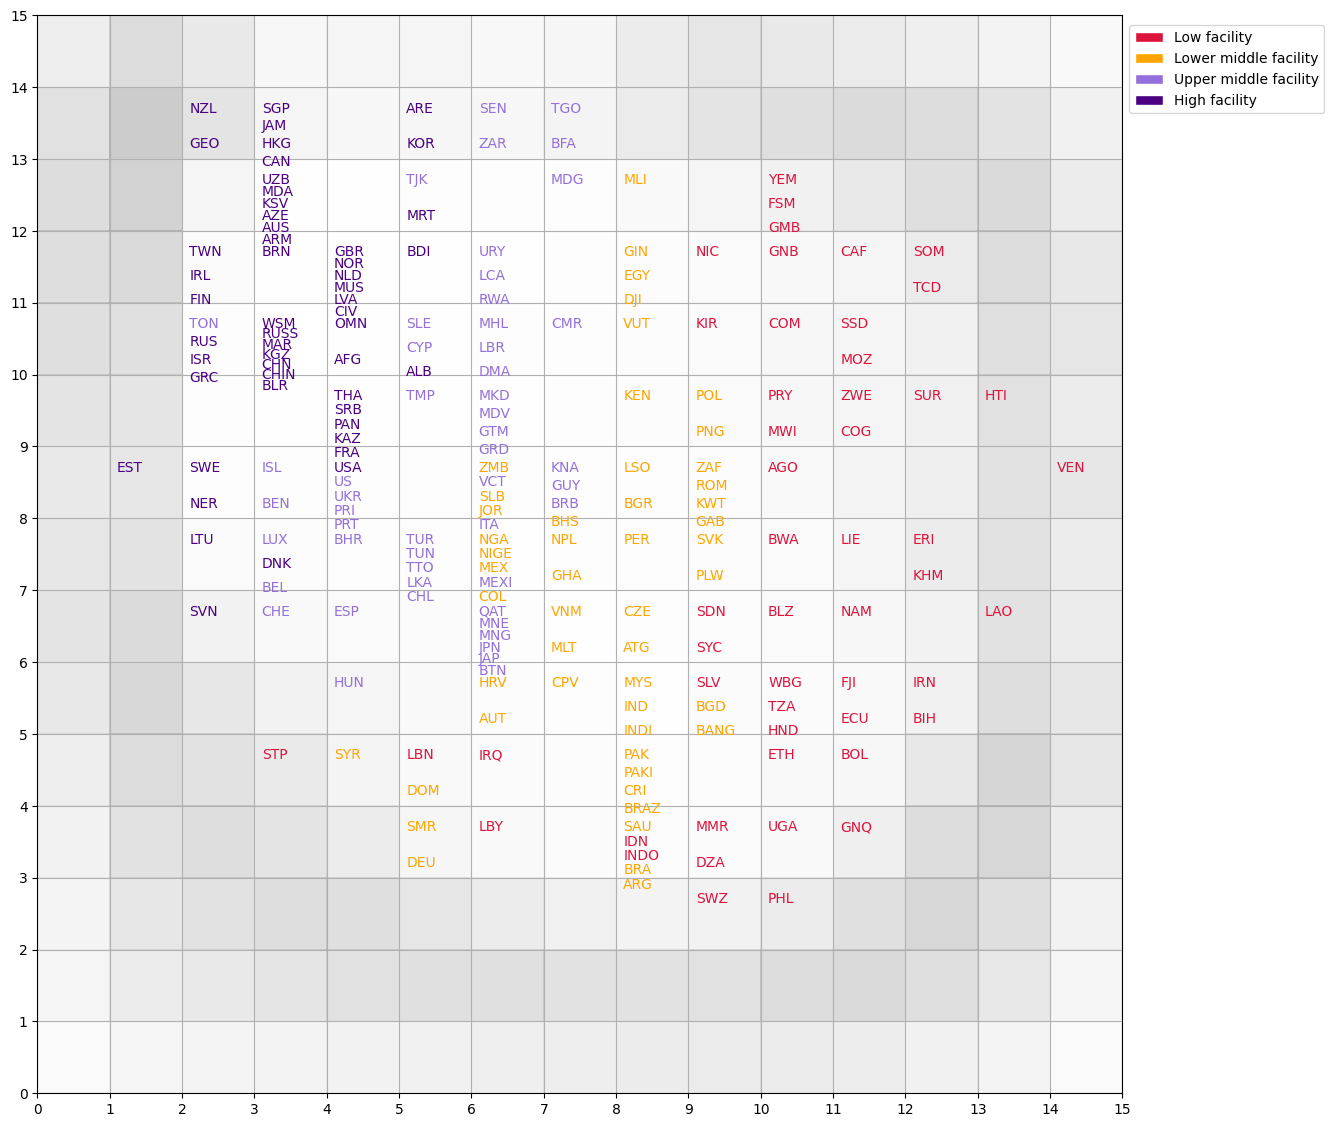

In [22]:
mapa.plot(country_start_colors, facility_colors)


A posição relativa de cada país no gráfico é determinada pela proximidade de cada país no conjunto de dados original com sete variáveis. Assim, estamos representando um conjunto de dados de dimensão mais alta em um gráfico de duas dimensões.

De modo geral o gráfico mostra que o índice de facilidade de fazer negócio caracteriza bem as distâncias relativas entre os países. Isto porque os países que estão no mesmo grupo de facilidade de fazer negócios aparecem mais próximos entre si formando clusters.

A preenchimento de fundo do gráfico representa a matriz de dissimilaridade entre da região em relação às observações que a rodeiam. Essa matriz pode ser usada para clusterizar as observações no mapa por meio de clusterização hierárquico ou mesmo o Kmeans, assim, as áreas mais escuras forneceriam as fronteiras entre os clusters.

No gráfico a seguir vamos plotar a posição relativa dos países e atribuir uma cor para cada país de acordo com a variável icome_group. Essa variável é uma classificação de países do Banco Mundial de acordo com o nível de renda, os países são classificados como:

##### Low income: Países de renda baixa;

##### Lower middle income: Países de renda média baixa;

##### Upper middle income: Países de renda média alta, o Brasil se encontra nesse grupo;

##### High income: Países de renda alta;

Desta forma, o gráfico abaixo irá mostrar a relação entre o nível de renda e as posições relativas entre os países:

In [23]:
income_colors = {
    'Low income': '#DC143C', 'Lower middle income': '#FFA500', 'Upper middle income': '#9370DB', 'High income': '#4B0082'
}
country_income_colors = [income_colors[income] for income in dados['income_group'].to_list()]

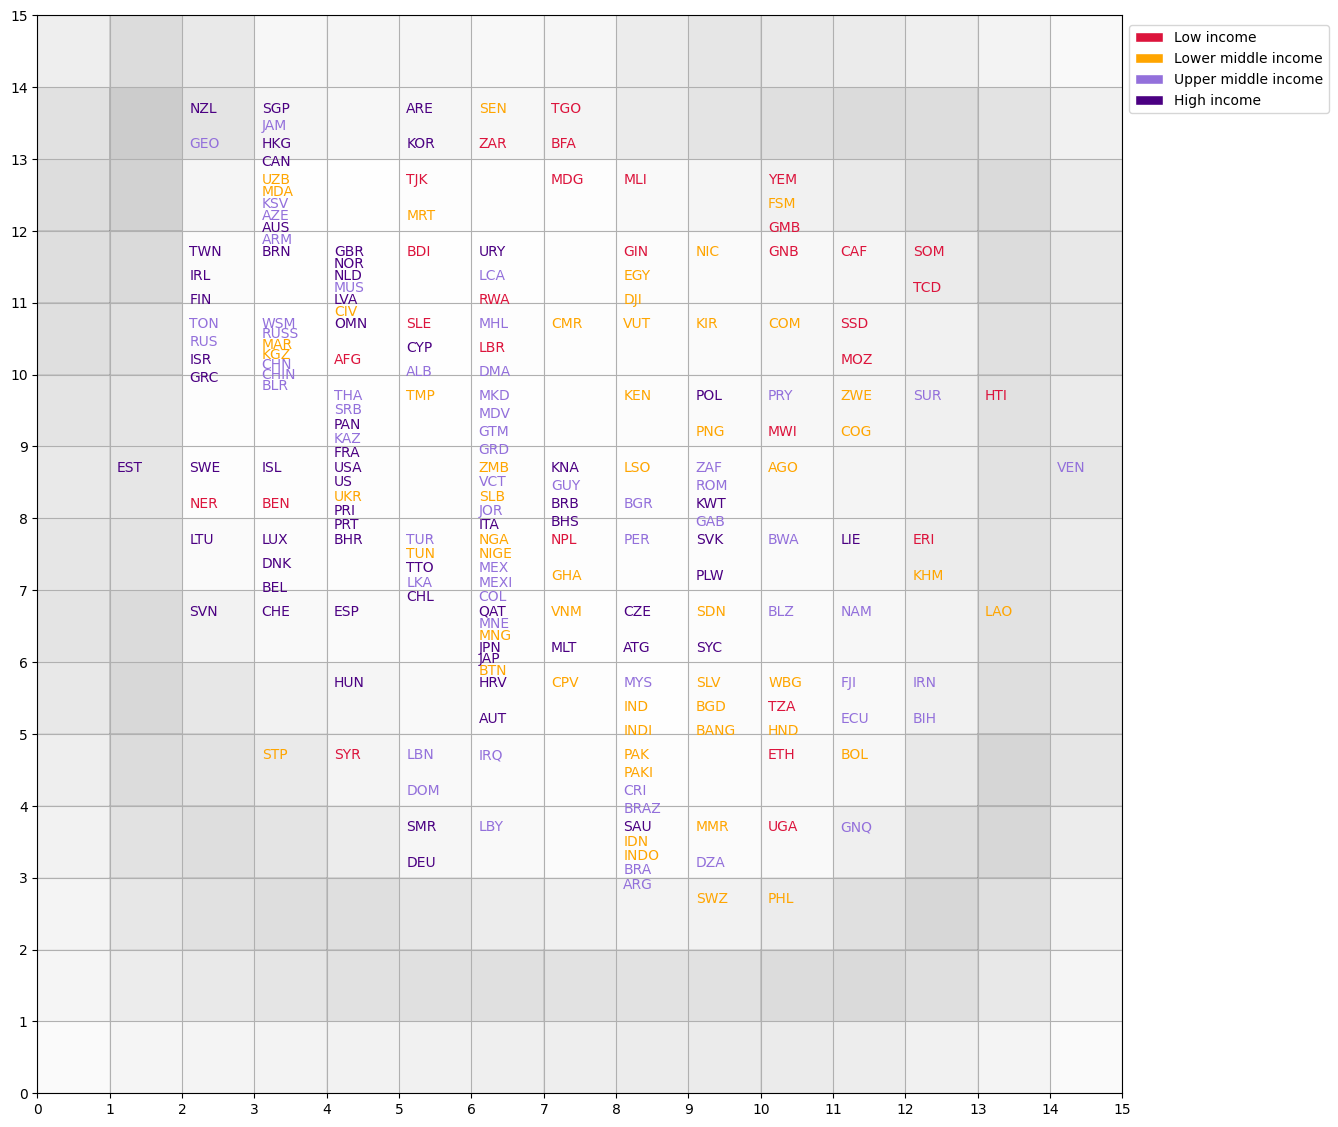

In [24]:
mapa.plot(labels_colors=country_income_colors, legend_colors=income_colors)


# https://www.youtube.com/watch?v=ogRu-JBRoyk